In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

In [3]:
# import os
# import torch
# import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# base_W2 = [0.251, 0.199, 0.170, 0.151]

# # --- [DATA LOADING AND PREPARATION - UNCHANGED EXCEPT NEW METRICS] ---
# PF_Cov_Diff_95CI = 0
# PF_RCov_Diff_95CI = 0
# ensemble_sizes = [4,6,8,10]

# data_folders = [
#     "linear_es_vs_l2/2025-08-14_20-05linear_1_10_60_8192_es_joint_CorrTerms",
#     "linear_es_vs_l2/2025-08-14_20-04linear_1_10_60_8192_l2_joint_CorrTerms",
#     "linear_es_vs_l2/2025-08-14_19-59linear_1_10_60_8192_es_joint_EtE-LRes_nst",
#     "linear_es_vs_l2/2025-08-14_20-04linear_1_10_60_8192_l2_joint_EtE-LRes_nst",
#     "linear_es_vs_l2/benchmark_linear_1.0_EnKF",
# ]

# method_names = [
#     'MNMEF-ES',
#     'MNMEF-L2',
#     'EtE-ES',        # always nst
#     'EtE-L2',
#     "EnKF",
# ]

# results = {}

# num_sizes = len(ensemble_sizes)
# for i, folder in enumerate(data_folders):
#     for ens_size in ensemble_sizes:
#         filename = f"output_records_{ens_size}.pt"
#         method_name = method_names[i]
#         data_file = os.path.join("save", folder, filename)

#         # Load file
#         data = torch.load(data_file, weights_only=True)

#         # Required metrics
#         cov_diff = data["nn"]['cov_diff']
#         w2_diff = data["nn"]['w2_diff']
#         t = data["time"]

#         # Initialize buckets
#         results.setdefault(method_name, {})
#         for key in ['cov_diff', 'w2_diff', 'rrmse', 'rcov_diff', 'time']:
#             results[method_name].setdefault(key, [])

#         # Append metrics
#         results[method_name]['cov_diff'].append(cov_diff)
#         results[method_name]['w2_diff'].append(w2_diff)
#         results[method_name]['time'].append(t)

# fig4, ax2 = plt.subplots(figsize=(14, 6))
# for key in results.keys():
#     ax2.plot(ensemble_sizes, results[key]['w2_diff'], marker='s', label=key)
# ax2.plot(ensemble_sizes, base_W2, marker='s', label="GT Baseline")
# ax2.set_title('Wasserstein-2 Comparison')
# ax2.set_xlabel('Ensemble Size (N)')
# ax2.set_ylabel('W2 Difference')
# ax2.set_xticks(ensemble_sizes)
# ax2.set_ylim(bottom=0)
# ax2.grid(True, linestyle='--', alpha=0.7)
# ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
# fig4.subplots_adjust(right=0.65)

# # --- Figure 5: Time ---
# fig5, ax5 = plt.subplots(figsize=(14, 6))
# for key in results.keys():
#     ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key)
# ax5.set_title('Time Comparison')
# ax5.set_xlabel('Ensemble Size (N)')
# ax5.set_ylabel('Time (s)')
# ax5.set_xticks(ensemble_sizes)
# ax5.grid(True, linestyle='--', alpha=0.7)
# ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))
# fig5.subplots_adjust(right=0.65)

# # Show all plots
# plt.show()


Saved to save/figures/linear_gaussian_w2diff_comparison.pdf and save/figures/linear_gaussian_w2diff_comparison_legend.pdf


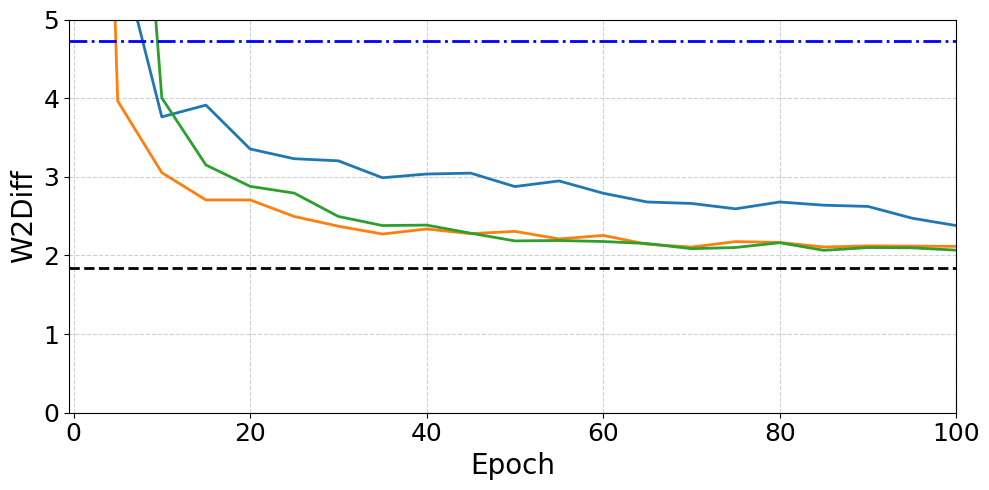

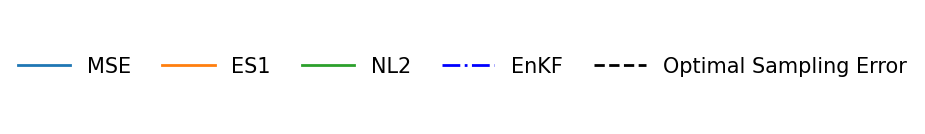

In [14]:
import torch
import os
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# =================== Style & layout knobs ===================
FIGSIZE_MAIN = (10, 5)
FIGSIZE_LEGEND = (10, 1.2)

# Line Styles
MAIN_LINE_WIDTH = 2.0

# GT Baseline (inherent uncertainty)
GT_COLOR = "k"
GT_LS = "--"
GT_LW = 2.0
GT_LABEL = "Optimal Sampling Error"

# EnKF Baseline
ENKF_COLOR = "blue"
ENKF_LS = "-."
ENKF_LW = 2.0
ENKF_LABEL = "EnKF"

# Axes ranges and grid
X_LIM = (-0.5, 100)
Y_LIM = (0, 5)
GRID_LS = "--"
GRID_ALPHA = 0.6

# Font sizes
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 15

# ===========================================================================

# --- Load Baselines ---
# Manually setting std to 0 implies we only care about the mean lines now
gt_mean = 1.837
enkf_mean = 4.726

folder_names = [
    '2025-12-23_08-08linear_1_10_60_8192_l2_joint_EtE-LRes20',
    '2025-12-23_08-21linear_1_10_60_8192_es_joint_EtE-LRes20',
    '2025-12-22_21-31linear_1_10_60_8192_nl2_joint_EtE-LRes20'
]
method_names = ['MSE', 'ES1', 'NL2']

# --- Main figure ---
fig_w2diff, ax_w2diff = plt.subplots(figsize=FIGSIZE_MAIN)

# 1. Plot Training Methods (Mean only)
for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', 'linear_gaussian_example', folder_name, 'training_records.pt')

    if not os.path.exists(file_name):
        print(f"Skipping {folder_name}: File not found.")
        continue

    data = torch.load(file_name, weights_only=True)
    mean_curve = np.array(data.get('mean_w2_diff', []))
    epochs = np.array(data.get('test_epochs', []))

    if len(mean_curve) == 0:
        continue

    # Plot Mean Line
    ax_w2diff.plot(
        epochs, mean_curve,
        linewidth=MAIN_LINE_WIDTH,
        label=method_names[i]
    )
    # Note: fill_between (std shading) removed as requested

# 2. Plot GT Baseline (Horizontal Line only)
ax_w2diff.axhline(
    y=gt_mean, 
    color=GT_COLOR, 
    linestyle=GT_LS, 
    linewidth=GT_LW, 
    label=GT_LABEL, 
    zorder=10
)

# 3. Plot EnKF Baseline (Horizontal Line only)
ax_w2diff.axhline(
    y=enkf_mean, 
    color=ENKF_COLOR, 
    linestyle=ENKF_LS, 
    linewidth=ENKF_LW, 
    label=ENKF_LABEL, 
    zorder=10
)

# Axes cosmetics
ax_w2diff.set_ylabel('W2Diff', fontsize=AXIS_LABEL_FONTSIZE)
ax_w2diff.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
ax_w2diff.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
ax_w2diff.set_xlim(*X_LIM)
ax_w2diff.set_ylim(*Y_LIM)
ax_w2diff.tick_params(axis='both', labelsize=TICK_FONTSIZE)
fig_w2diff.tight_layout()

# --- Legend Figure ---
# Order: Methods -> EnKF -> GT (Optimal Sampling Error)
desired_order = method_names + [ENKF_LABEL, GT_LABEL]

handles, labels = ax_w2diff.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}

ordered_handles = [label_to_handle[lab] for lab in desired_order if lab in label_to_handle]
ordered_labels = [lab for lab in desired_order if lab in label_to_handle]

fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')
ax_legend.legend(
    ordered_handles, ordered_labels,
    loc='center',
    ncol=len(ordered_labels),
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.5,
    columnspacing=1.5
)
fig_legend.tight_layout(pad=0.2)

# --- Save ---
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)
main_path = os.path.join(out_dir, "linear_gaussian_w2diff_comparison.pdf")
legend_path = os.path.join(out_dir, "linear_gaussian_w2diff_comparison_legend.pdf")

fig_w2diff.savefig(main_path, format="pdf", bbox_inches="tight", pad_inches=0.1)
fig_legend.savefig(legend_path, format="pdf", bbox_inches="tight", pad_inches=0.1)

print(f"Saved to {main_path} and {legend_path}")

plt.show(fig_w2diff)
plt.show(fig_legend)